In [80]:
import os #path handling
import numpy as np #import numpy drives sklearn to use numpy arrays instead of python lists
import pandas as pd #CSV and dataframe handling
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split #Data set splitting functions
from sklearn.metrics import confusion_matrix #Confusion matrix

from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier #kNN classifier
from sklearn.ensemble import AdaBoostClassifier

The goal of this project is to test different classifiers in order to see if we can determine if a passenger of the Titanic has survived, knowing only a few parameters like its age, sex or the ticket class.

### Getting the data

In [ ]:
print("Current working directory: {0}".format(os.getcwd()))
dataPath = '' # path to folder containing the titanic passengers data
dataFileTraining = os.path.join(dataPath,'train.csv') # data file to use
dataFileTest=os.path.join(dataPath,'test.csv') # data file to use
dataFileSurvived=os.path.join(dataPath,'gender_submission.csv')

Current working directory: C:\Users\Samy\ISAE_data_analysis_students\titanic


### Verifying the data relevancy

In [3]:
# we assign column names based on the description file. 'FType' stands for 'Flower Type'
fullDF1 = pd.read_csv(dataFileTraining,header=0,names=['PassengerId','Survived','Pclass','Name','Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']) 
fullDF2 = pd.read_csv(dataFileTest,header=0,names=['PassengerId','Pclass','Name','Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']) 
fullDF3=pd.read_csv(dataFileSurvived,header=0,names=['PassengerId','Survived']) 
fullDF2.insert(1,'Survived', fullDF3['Survived'])

fullDF=pd.concat([fullDF1, fullDF2], axis=0)
fullDF.reset_index(drop=True, inplace=True)
fullDF['Fare'][1043] = np.nanmean(fullDF['Fare'])

<ipython-input-3-ee7a147a142a>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fullDF['Fare'][1043] = np.nanmean(fullDF['Fare'])


In [ ]:
age_mean = np.nanmean(fullDF['Age'])
age_std = np.nanstd(fullDF['Age'])
print(age_mean)

29.881137667304014


### Feature engineering & performances

In [ ]:
# Let's define a mapping function from 'Sex' to a class number
def dataMap_Sex(FType):
  """
  Data mapping function. Assigns a class number, given a class name
  Args:
    FType: (str) Sex type
  Returns: (int) Sex class
  """
  if FType != FType :
    f = np.random.randint(0,2)    
    return f
  else :
    mapping = {'female': 0,
            'male': 1}
    return mapping[FType]

In [ ]:
# Let's define a mapping function from 'Fmbarcation' to a class number
def dataMap_Emb(FType):
  """
  Data mapping function. Assigns a class number, given a class name
  Args:
    FType: (str) Embarcation type
  Returns: (int) Embarcation class
  """
  if FType != FType :
    f = np.random.randint(0,2)    
    return f
  else :
    mapping = {'S': 0,
            'C': 1, 'Q' : 2}
    return mapping[FType]


In [7]:
# Let's define a mapping function from 'Flower type' to a class number
def dataMap_age(FType):
  if FType != FType:
    return np.random.randn(1)*age_std + age_mean
  else :
    return FType  


In [8]:
def dataNormMax(trainData, testData):
    """
    On normalise les données entre 0 et 1
    """
    maxx = 1
    for item in trainData:
        maxx = np.nanmax(trainData[item])
        trainData[item]=trainData[item]/maxx
        testData[item]=testData[item]/maxx   
    

In [9]:
def dataNormVar(trainData, testData):
    for item in trainData:
        if item!='PassengerId' and item!='New_Sex':
            mean=np.nanmean(trainData[item])
            std=np.nanstd(trainData[item])
            trainData[item]=(trainData[item]-mean)/std     
            testData[item]=(testData[item]-mean)/std
            

In [10]:
def performances(testCM, type = 'titanic'):
    
    if type == 'titanic':
    
        TP = testCM[1,1]
        FP = testCM[0,1]
        TN = testCM[0,0]
        FN = testCM[1,0]

        fallout = FP/(FP + TN)
        recall = TP/(TP + FN)
        accuracy = (TP + TN)/(TP + FP + TN + FN)
        precision = TP/(TP + FP)

        print('\t\t\t\t\t------------------------')
        print('\t\t\t\t\t| Fallout   | ', round(fallout,5), '|')
        print('\t\t\t\t\t------------------------')
        print('\t\t\t\t\t| Recall    | ', round(recall,5), '|')
        print('\t\t\t\t\t------------------------')
        print('\t\t\t\t\t| Accuracy  | ', round(accuracy,5), '|')
        print('\t\t\t\t\t------------------------')
        print('\t\t\t\t\t| Precision | ', round(precision,5), '|')
        print('\t\t\t\t\t------------------------')

        print("\n\n\t\t\t\t\t\t\tDesigned by Yvan & Tom ©")
        print("\t\t\t\t\t\t\t------------------------")

    else:
        # Building matrices of size 2x2
        # First type of flower :
        testCM_1[1,1] = testCM[0,0]
        testCM_1[0,1] = testCM[1,1] + testCM[1,2]
        testCM_1[1,0] = testCM_1[1,0] + testCM[2,0] 
        testCM_1[0,0] = testCM[1,1] + testCM[2,2]
        
        # Second type of flower :
        testCM_2[1,1] = testCM[1,1]
        testCM_2[0,1] = testCM[0,1] + testCM[2,1]
        testCM_2[1,0] = testCM_1[1,0] + testCM[1,2] 
        testCM_2[0,0] = testCM[0,0] + testCM[2,2]
        
        # Third type of flower :
        testCM_3[1,1] = testCM[2,2]
        testCM_3[0,1] = testCM[0,2] + testCM[1,2]
        testCM_3[1,0] = testCM_1[2,0] + testCM[2,1] 
        testCM_3[0,0] = testCM[0,0] + testCM[1,1]
        
        print("type 1")
        performances(testCM_1, type = 'titanic')
        print("type 2")
        performances(testCM_2, type = 'titanic')
        print("type 3")
        performances(testCM_3, type = 'titanic')
        

### Feature engineering after data organisation

In [11]:
# Let's apply the mapping function to the input data and create a new column called 'Y'
fullDF['New_Sex'] = [dataMap_Sex(item) for item in fullDF['Sex']]

In [12]:
# Let's apply the mapping function to the input data and create a new column called 'Y'
fullDF['New_Embarked'] = [dataMap_Emb(item) for item in fullDF['Embarked']]

In [13]:
# Let's apply the mapping function to the input data and create a new column called 'Y'
fullDF['New_Age'] = [dataMap_age(item) for item in fullDF['Age']]

In [14]:
# Separate data from classes
dataDF = fullDF[['PassengerId','Pclass','New_Sex','New_Age', 'SibSp', 'Parch', 'Fare', 'New_Embarked']]
classDF = fullDF['Survived']

### Data sets separation

In [140]:
# Let's split the data into training data, and test data. Same splitting should be applied to classes.
# Here, the test data size is 10% of the full dataset
trainData,testData,trainY,testY = train_test_split(dataDF,classDF,test_size=0.2)

dataNormMax(trainData, testData)
#dataNormVar(trainData, testData)

X = trainData
X2 = testData
pca = PCA()
pca.fit(X)
pca.transform(X)
pca.transform(X2)

<ipython-input-8-337cd7a54bea>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainData[item]=trainData[item]/maxx
<ipython-input-8-337cd7a54bea>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testData[item]=testData[item]/maxx


array([[-0.33833284, -0.2352096 ,  0.43315091, ...,  0.03435219,
        -0.03803592, -0.05871106],
       [-0.37553681, -0.10733417,  0.24245586, ..., -0.07362729,
        -0.02800741, -0.0234285 ],
       [-0.40185164, -0.11297647, -0.17391703, ..., -0.06730486,
         0.0086035 ,  0.0309126 ],
       ...,
       [-0.39166963, -0.18389753, -0.39226891, ..., -0.11470843,
         0.01003333,  0.03028005],
       [-0.37651486, -0.17398739,  0.23026588, ...,  0.09449073,
        -0.01706336, -0.03057399],
       [ 0.73979911,  0.639247  , -0.49367944, ..., -0.00654471,
        -0.06810276,  0.00984774]])

## kNN

### Training the classifier

In [ ]:
kNN = KNeighborsClassifier(n_neighbors=10,algorithm='kd_tree',metric='minkowski',p=2,n_jobs=-1)
kNN.fit(trainData,trainY)

### Performances of the classifier on the training data set

In [ ]:
trainPredictions = kNN.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

### Performances of the classifier on the training data set

In [ ]:
predictions = kNN.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

In [ ]:
plt.matshow(testCM)

In [ ]:
performances(testCM)

## kNN - with PCA

### Training the classifieur 

In [ ]:
kNN_pca = KNeighborsClassifier(n_neighbors=10,algorithm='kd_tree',metric='minkowski',p=2,n_jobs=-1)
kNN_pca.fit(X,trainY)

### Performances of the classifier on the training data set

In [ ]:
trainPredictions = kNN_pca.predict(X)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

### Performances of the classifier on the test data set

In [ ]:
predictions = kNN_pca.predict(X2)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

In [ ]:
plt.matshow(testCM)

In [ ]:
performances(testCM)

## Linear classifier

### Training the classifieur

In [ ]:
SSS = LinearSVC(max_iter = 100000)
SSS.fit(trainData,trainY)

### Performances of the classifier on the training data set

In [ ]:
trainPredictions = SSS.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

### Performances of the classifier on the test data set

In [ ]:
predictions = SSS.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

In [ ]:
plt.matshow(testCM)

In [ ]:
performances(testCM)

## Linear Classifier - with PCA

### Training the classifieur 

In [ ]:
SSS_pca = LinearSVC(max_iter = 100000)
SSS_pca.fit(X,trainY)

### Performances of the classifier on the training data set

In [ ]:
trainPredictions = SSS_pca.predict(X)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

### Performances of the classifier on the training data set

In [ ]:
predictions = SSS_pca.predict(X2)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

In [ ]:
plt.matshow(testCM)

In [ ]:
performances(testCM)

## Classifier Neural Network

### Training the CNN

In [16]:
MMM = MLPClassifier(max_iter = 100000)
MMM.fit(trainData,trainY)

MLPClassifier(max_iter=100000)

### Performances of the classifier on the training data set

In [17]:
trainPredictions = MMM.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[621  23]
 [ 83 320]]


There are some false negatives, but they remain in minority with respect to the true positives.

### Performances of the classifier on the test data set

In [18]:
predictions = MMM.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[158  13]
 [ 20  71]]


There are som false negatives, but we retain a good ratio of false positives to true positives.

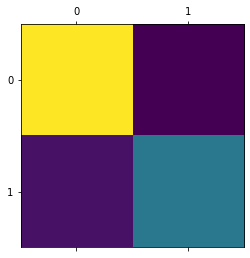

In [19]:
# You can also plot the confusion matrix
plt.matshow(testCM)


We visualise the previous results through a matrix.

In [20]:
performances(testCM)

					------------------------
					| Fallout   |  0.07602 |
					------------------------
					| Recall    |  0.78022 |
					------------------------
					| Accuracy  |  0.87405 |
					------------------------
					| Precision |  0.84524 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


These are very good results, with a fallout of only 7.6%, and an accuracy of over 80%.

## Non-linear classifier

### Training the classifier 

In [21]:
NL = SVC(max_iter = 100000)
NL.fit(trainData,trainY)

SVC(max_iter=100000)

### Performances of the classifier on the training data set

In [22]:
trainPredictions = NL.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[601  43]
 [ 94 309]]


### Performances of the classifier on the test data set

In [23]:
predictions = NL.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[159  12]
 [ 25  66]]


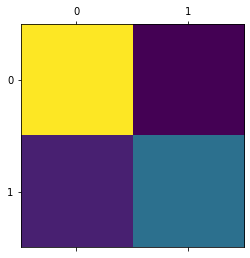

In [24]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [25]:
performances(testCM)

					------------------------
					| Fallout   |  0.07018 |
					------------------------
					| Recall    |  0.72527 |
					------------------------
					| Accuracy  |  0.85878 |
					------------------------
					| Precision |  0.84615 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


## Classifieur Non Linéaire - avec PCA

### Training of the classifier

In [ ]:
NL_pca = SVC(max_iter = 100000)
NL_pca.fit(X,trainY)

### Performances of the classifier on the training data set

In [ ]:
trainPredictions = NL_pca.predict(X)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

### Performances of the classifier on the test data set

In [ ]:
predictions = NL_pca.predict(X2)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

In [ ]:
plt.matshow(testCM)

In [ ]:
performances(testCM)

## Decision Tree 

### Training the classifier

In [26]:
DTC = DecisionTreeClassifier()
DTC.fit(trainData,trainY)

DecisionTreeClassifier()

### Performances of the classifier on the training data set

In [27]:
trainPredictions = DTC.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[644   0]
 [  0 403]]


### Performances of the classifier on the test data set

In [28]:
predictions = DTC.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[141  30]
 [ 21  70]]


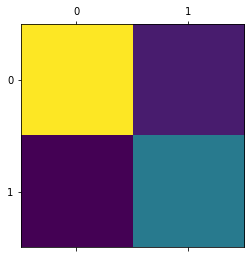

In [29]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [30]:
performances(testCM)

					------------------------
					| Fallout   |  0.17544 |
					------------------------
					| Recall    |  0.76923 |
					------------------------
					| Accuracy  |  0.80534 |
					------------------------
					| Precision |  0.7 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


## Decision Tree - with PCA

### Training the classfier

In [31]:
DTC_pca = DecisionTreeClassifier()
DTC_pca.fit(X,trainY)

DecisionTreeClassifier()

### Performances of the classifier on the training data set

In [32]:
trainPredictions = DTC_pca.predict(X)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[644   0]
 [  0 403]]


### Performances of the classifier on the test data set

In [33]:
predictions = DTC_pca.predict(X2)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[142  29]
 [ 17  74]]


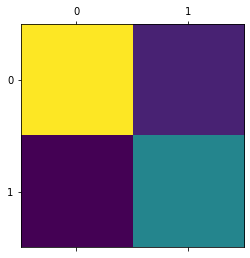

In [34]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [35]:
performances(testCM)

					------------------------
					| Fallout   |  0.16959 |
					------------------------
					| Recall    |  0.81319 |
					------------------------
					| Accuracy  |  0.82443 |
					------------------------
					| Precision |  0.71845 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


## Bagging

### KNN

In [130]:
B_kNN = BaggingClassifier(base_estimator=KNeighborsClassifier(), n_estimators=20, random_state=0, max_samples=0.6)
B_kNN.fit(trainData,trainY)

B_kNN_pca = BaggingClassifier(base_estimator=KNeighborsClassifier(), n_estimators=20, random_state=0, max_samples=0.6)
B_kNN_pca.fit(X,trainY)

BaggingClassifier(base_estimator=KNeighborsClassifier(), max_samples=0.6,
                  n_estimators=20, random_state=0)

In [131]:
trainPredictions = B_kNN.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

trainPredictions = B_kNN_pca.predict(X)
trainCM2 = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM2)

[[614  30]
 [ 84 319]]
[[614  30]
 [ 84 319]]


In [132]:
predictions = B_kNN.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

predictions = B_kNN_pca.predict(X2)
testCM2 = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM2)

[[150  21]
 [ 21  70]]
[[150  21]
 [ 21  70]]


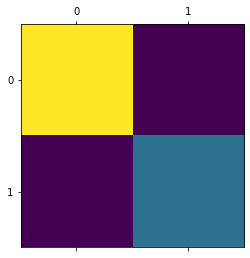

In [120]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [121]:
performances(testCM)

					------------------------
					| Fallout   |  0.12281 |
					------------------------
					| Recall    |  0.76923 |
					------------------------
					| Accuracy  |  0.83969 |
					------------------------
					| Precision |  0.76923 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


### SVC

In [133]:
B_SVC = BaggingClassifier(base_estimator=SVC(), n_estimators=20, random_state=0, max_samples=0.6)
B_SVC.fit(trainData,trainY)

B_SVC_pca = BaggingClassifier(base_estimator=SVC(), n_estimators=20, random_state=0, max_samples=0.6)
B_SVC_pca.fit(X,trainY)

BaggingClassifier(base_estimator=SVC(), max_samples=0.6, n_estimators=20,
                  random_state=0)

In [134]:
trainPredictions = B_SVC.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

trainPredictions = B_SVC_pca.predict(X)
trainCM2 = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM2)

[[594  50]
 [ 91 312]]
[[594  50]
 [ 91 312]]


In [135]:
predictions = B_SVC.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

predictions = B_SVC_pca.predict(X2)
testCM2 = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM2)

[[157  14]
 [ 23  68]]
[[157  14]
 [ 23  68]]


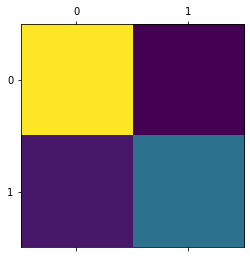

In [125]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [126]:
performances(testCM)

					------------------------
					| Fallout   |  0.08187 |
					------------------------
					| Recall    |  0.74725 |
					------------------------
					| Accuracy  |  0.85878 |
					------------------------
					| Precision |  0.82927 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


### MLP

In [136]:
B_MLP = BaggingClassifier(base_estimator=MLPClassifier(max_iter = 100000), n_estimators=20, random_state=0, max_samples=0.6)
B_MLP.fit(trainData,trainY)

B_MLP_pca = BaggingClassifier(base_estimator=MLPClassifier(max_iter = 100000), n_estimators=20, random_state=0, max_samples=0.6)
B_MLP_pca.fit(X,trainY)

BaggingClassifier(base_estimator=MLPClassifier(max_iter=100000),
                  max_samples=0.6, n_estimators=20, random_state=0)

In [137]:
trainPredictions = B_MLP.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

trainPredictions = B_MLP_pca.predict(X)
trainCM2 = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM2)

[[610  34]
 [ 93 310]]
[[610  34]
 [ 93 310]]


In [138]:
predictions = B_MLP.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

predictions = B_MLP.predict(X2)
testCM2 = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM2)

[[159  12]
 [ 25  66]]
[[159  12]
 [ 25  66]]


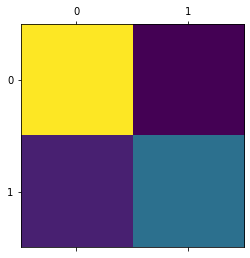

In [139]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [64]:
performances(testCM)

					------------------------
					| Fallout   |  0.07602 |
					------------------------
					| Recall    |  0.76923 |
					------------------------
					| Accuracy  |  0.87023 |
					------------------------
					| Precision |  0.84337 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


### DecisionTree

In [65]:
B_DTC = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=20, random_state=0)
B_DTC.fit(trainData,trainY)

BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=20,
                  random_state=0)

In [66]:
trainPredictions = B_DTC.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[644   0]
 [  3 400]]


In [67]:
predictions = B_DTC.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[145  26]
 [ 15  76]]


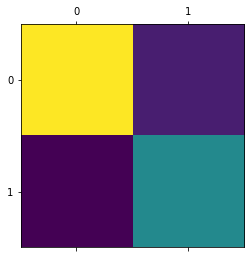

In [68]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [69]:
performances(testCM)

					------------------------
					| Fallout   |  0.15205 |
					------------------------
					| Recall    |  0.83516 |
					------------------------
					| Accuracy  |  0.84351 |
					------------------------
					| Precision |  0.7451 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


## Random Forest

In [72]:
B_RFC = RandomForestClassifier(n_estimators=20)
B_RFC.fit(trainData,trainY)

RandomForestClassifier(n_estimators=20)

In [73]:
trainPredictions = B_RFC.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[642   2]
 [  3 400]]


In [74]:
predictions = B_RFC.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[156  15]
 [ 21  70]]


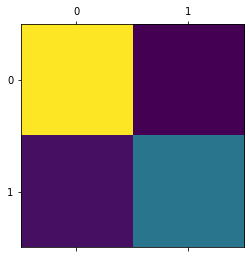

In [75]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [76]:
performances(testCM)

					------------------------
					| Fallout   |  0.08772 |
					------------------------
					| Recall    |  0.76923 |
					------------------------
					| Accuracy  |  0.8626 |
					------------------------
					| Precision |  0.82353 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


## Boosting

### SVC

In [112]:
A_SVC = AdaBoostClassifier(base_estimator=SVC(), n_estimators=100, algorithm='SAMME')
A_SVC.fit(trainData,trainY)

AdaBoostClassifier(algorithm='SAMME', base_estimator=SVC(), n_estimators=100)

In [113]:
trainPredictions = A_SVC.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[644   0]
 [403   0]]


In [114]:
predictions = A_SVC.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[171   0]
 [ 91   0]]


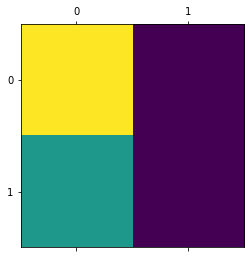

In [115]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [116]:
performances(testCM)

					------------------------
					| Fallout   |  0.0 |
					------------------------
					| Recall    |  0.0 |
					------------------------
					| Accuracy  |  0.65267 |
					------------------------
					| Precision |  nan |
					------------------------


							Designed by Yvan & Tom ©
							------------------------


<ipython-input-10-46f16a406a28>:13: RuntimeWarning: invalid value encountered in longlong_scalars
  precision = TP/(TP + FP)


### DecisionTree

In [107]:
A_DTC = AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=100), n_estimators=100)
A_DTC.fit(trainData,trainY)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=100),
                   n_estimators=100)

In [108]:
trainPredictions = A_DTC.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[644   0]
 [  0 403]]


In [109]:
predictions = A_DTC.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[141  30]
 [ 18  73]]


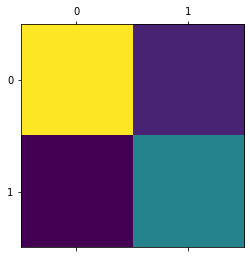

In [110]:
# You can also plot the confusion matrix
plt.matshow(testCM)

In [111]:
performances(testCM)

					------------------------
					| Fallout   |  0.17544 |
					------------------------
					| Recall    |  0.8022 |
					------------------------
					| Accuracy  |  0.81679 |
					------------------------
					| Precision |  0.70874 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------
